In [1]:
# ── Imports and project root ───────────────────────────────────────────────
%cd ..
from __future__ import annotations
import glob
import h5py
import torch
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import xarray as xr
from scipy.optimize import curve_fit
from scipy.special import ndtr  # standard normal CDF
from scipy.stats import gaussian_kde

PROJECT_ROOT = Path(".").resolve()

/Users/maperezc/Downloads/wildfires


In [2]:
# ── Case study parameters ──────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "data"

# Date — NOTE: mmdd column in hotspot CSV is int64 (118, not "0118")
FIRE_DATE   = "2026-01-18"
TARGET_DAY  = "".join(FIRE_DATE.split("-")[1:]) 

# ── L2 file paths (structure verified in docs/l2_file_structure_jan18.txt) ─
NO2_L2_PATTERN   = DATA_DIR / TARGET_DAY / "S5P_OFFL_L2__NO2____2026*"
AER_LH_L2_PATTERN = DATA_DIR / TARGET_DAY / "S5P_OFFL_L2__AER_LH_2026*"
AER_AI_L2_PATTERN = DATA_DIR / TARGET_DAY / "S5P_OFFL_L2__AER_AI_2026*"

NO2_L2_PATH   = Path(glob.glob(str(NO2_L2_PATTERN))[0])
AER_LH_L2_PATH = Path(glob.glob(str(AER_LH_L2_PATTERN))[0])
AER_AI_L2_PATH = Path(glob.glob(str(AER_AI_L2_PATTERN))[0])

# Paths
HOTSPOT_CSV:    Path = DATA_DIR  / "daily_dominant_hotspot_summary.csv"
ERA5_SFC_PATH: Path = DATA_DIR  / "ERA5_winds.nc"
ERA5_PL_PATH:   Path = DATA_DIR  / "ERA5_winds_pressure_levels.nc"
OUT_DIR:       Path = PROJECT_ROOT  / "outputs" / "nox_final" / TARGET_DAY
OUT_DIR.mkdir(parents=True, exist_ok=True)


QA_THRESH   = 0.5       # Jin et al. (2021): retain smoke-affected pixels
AI_THRESHOLD = 2.0  # Consistent with hotspot_analysis.py (CLAUDE.md)
AER_LH_MIN_PIXELS  = 0  # Minimum valid AER_LH pixels for pressure selection
QA_UINT8: int          = int(QA_THRESH * 100)

In [3]:
# ── Physical constants ─────────────────────────────────────────────────────
NO2_MOLAR_MASS_G_PER_MOL = 46.005  # g mol⁻¹
EARTH_RADIUS_KM = 6_371.0          # WGS-84 mean
M_PER_DEG_LAT = 111_320.0          # m deg⁻¹
NOX_NO2_RATIO_GAMMA = 1.32         # Jin et al. (2021) Table S1


# ── Domain expansion for large Chilean plumes ─────────────────────────────
# Paper (Jin et al. 2021) uses ±300 km downwind, ±100 km cross-wind for
# global fires with typical plume lengths of tens to hundreds of km.
# January 2026 Chilean fires produced plumes extending ~1000 km due to
# strong synoptic flow and sustained multi-day burning — using the paper's
# 200 km extraction radius would truncate the plume and underestimate x₀.
EXTRACTION_RADIUS_KM     = 300   # expanded from paper's 200 km
CROSSWIND_INTEGRATION_KM = 100   # expanded from paper's 100 km
DOWNWIND_MAX_KM          = 300  # expanded from paper's ~300 km
DOWNWIND_MIN_KM          = -100  # expanded from paper's ~300 km
GRID_SPACING_DEG         = 0.05  # kept from paper exactly (≈ 5.5 km)
EARTH_RADIUS_KM          = 6371.0

# ── Grid constants (using expanded domain) ────────────────────────────────
GRID_DY_KM   = 5.5      # isotropic spacing (paper uses 0.05° ≈ 4.44–5.57 km)
X_MAX_KM     = float(DOWNWIND_MAX_KM)
X_MIN_KM     = float(DOWNWIND_MIN_KM)
Y_MAX_KM     = float(CROSSWIND_INTEGRATION_KM)
GRID_DY_M    = GRID_DY_KM * 1000.0

# Chile bounding box (from CLAUDE.md)
LAT_MIN, LAT_MAX = -46.83, -26.83
LON_MIN, LON_MAX = -83.05, -43.05

In [4]:
NO2_L2_PATH

PosixPath('/Users/maperezc/Downloads/wildfires/data/0118/S5P_OFFL_L2__NO2____20260118T173523_20260118T191653_42837_03_020901_20260120T100137.nc')

In [5]:
from src.data_helpers import load_no2_l2, load_aer_ai, load_aer_lh, get_modis_hotspot

no2_data = load_no2_l2(NO2_L2_PATH, 
                lat_min = LAT_MIN,
                lat_max = LAT_MAX,
                lon_min = LON_MIN,
                lon_max = LON_MAX,
                qa_threshold = QA_UINT8)

ai_data = load_aer_ai(AER_AI_L2_PATH,
                lat_min = LAT_MIN,
                lat_max = LAT_MAX,
                lon_min = LON_MIN,
                lon_max = LON_MAX,
                qa_threshold = QA_UINT8)

alh_data = load_aer_lh(AER_LH_L2_PATH,
                lat_min = LAT_MIN,
                lat_max = LAT_MAX,
                lon_min = LON_MIN,
                lon_max = LON_MAX,
                qa_threshold = QA_UINT8)

modis = get_modis_hotspot(HOTSPOT_CSV,
                        FIRE_DATE,
                        lat_min = LAT_MIN,
                        lat_max = LAT_MAX,
                        lon_min = LON_MIN,
                        lon_max = LON_MAX,
                        )

FIRE_LAT, FIRE_LON = modis["dominant_lat"].values[0], modis["dominant_lon"].values[0]

print(f"Jan 18 MODIS detections (filtered): {len(modis)}")
print(f"FRP: {modis['dominant_frp_mw'].values[0]} MW")
print(f"\nUsing fire centre: ({FIRE_LAT:.4f}°N, {FIRE_LON:.4f}°E)")

Jan 18 MODIS detections (filtered): 1
FRP: 953.6838 MW

Using fire centre: (-37.5484°N, -72.5545°E)


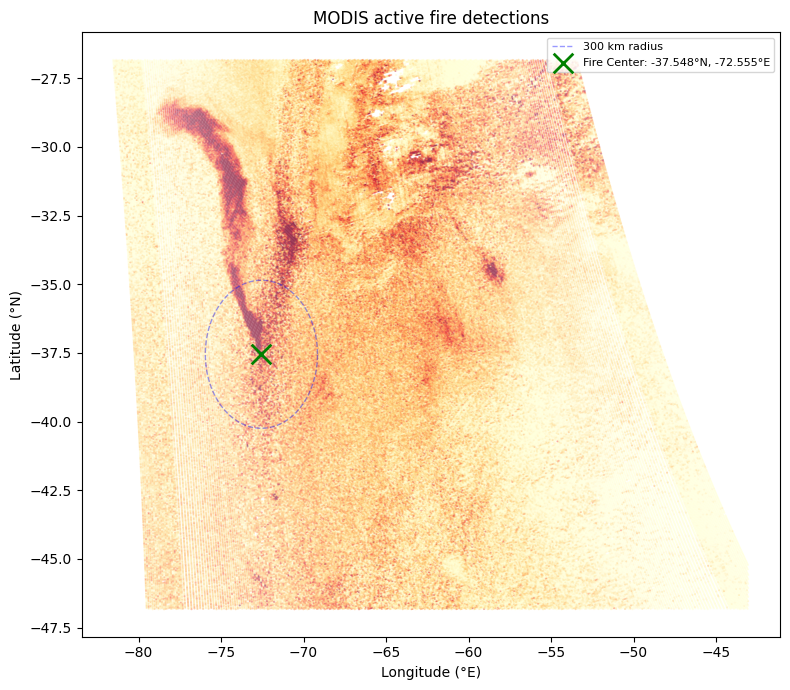

In [6]:
lat_domain = no2_data["lat"]
lon_domain = no2_data["lon"]
no2_domain = no2_data["no2"]
time_utc_str = no2_data["time"]

# ── Map: MODIS detections coloured by cluster ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

# Background: scatter L2 domain pixels
# (minp, maxp defined in cell 4 from no2_domain)
_minp_bg = np.nanpercentile(no2_domain[no2_domain > 0] * 1e6, 1) if 'no2_domain' in dir() else 0
_maxp_bg = np.nanpercentile(no2_domain[no2_domain > 0] * 1e6, 99) if 'no2_domain' in dir() else 25
im = ax.scatter(lon_domain, lat_domain, c=no2_domain * 1e6,
                vmin=_minp_bg, vmax=_maxp_bg, cmap="YlOrRd", alpha=0.4, s=0.3,
                rasterized=True)

# 20 km radius circle around Method B centroid
theta_c = np.linspace(0, 2*np.pi, EXTRACTION_RADIUS_KM)
r_lat = EXTRACTION_RADIUS_KM / (M_PER_DEG_LAT / 1000.0)
r_lon = EXTRACTION_RADIUS_KM / ((M_PER_DEG_LAT / 1000.0) * np.cos(np.radians(FIRE_LAT)))
ax.plot(FIRE_LON + r_lon * np.cos(theta_c),
        FIRE_LAT + r_lat * np.sin(theta_c),
        "b--", alpha=0.4, lw=1, label=f"{EXTRACTION_RADIUS_KM} km radius")

ax.scatter(FIRE_LON, FIRE_LAT, marker="x", s=200, c="green",
           linewidths=2, label=f"Fire Center: {FIRE_LAT:.3f}°N, {FIRE_LON:.3f}°E")

ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.set_title(f"MODIS active fire detections")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(OUT_DIR / "eda_s2_modis_clustering.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Section 3 — ERA5 Vertical Wind Profile at Overpass Time

**Log-pressure interpolation** (Jin et al. 2021):

    u_alh = interp(log(p_alh), log(p_levels_sorted_asc), u_sorted_asc)

ERA5 pressure levels are stored **descending** (1000→1 hPa); we must sort
them ascending before calling `np.interp`.

Overpass time: 13:30 CLST (UTC−3) → 16:30 UTC. Nearest ERA5 step: 17:00 UTC.

---
## Section 3a — Aerosol Injection Pressure (AER_AI + AER_LH)

Jin et al. (2021) use the **aerosol layer height (AER_LH)** product to identify
the pressure level at which NOₓ is being transported. ERA5 winds are then
extracted at that pressure level rather than at 10 m.

**Implementation here** uses `select_injection_pressure`, which:
1. Builds an **AER_AI plume mask** (AI > 2.0, QA ≥ 0.5) as the spatial selector
2. Matches **AER_LH pixels** within 15 km of the plume mask via a KD-tree
3. Reports median, max, and IQR of `aerosol_mid_pressure` inside the plume

**Methodological note:** The paper's implementation uses a 50 km radius around
the *fire centre* to extract AER_LH pixels. This notebook uses the *plume mask*
as the spatial selector, which is more appropriate for the large Chilean plumes
(> 500 km extent) where fire-centre-only extraction would miss the aerosol signal.

**AER_LH data structure (verified):**
- `PRODUCT/aerosol_mid_pressure` — Pa, float32, shape (1, 4172, 448)
- 448 ground pixels (vs 450 for NO2/AER_AI) due to different slit mask
- QA ≥ 0.5 applied; O₂ A-band retrieval degrades over thick smoke

In [7]:
from src.wind_helpers import select_injection_pressure, _haversine_km, _latlon_to_xyz
from scipy.spatial import cKDTree

psel = select_injection_pressure(
    ai_raw=ai_data["ai"],
    ai_lat=ai_data["lat"],
    ai_lon=ai_data["lon"],
    alh_pres_raw=alh_data["alh_pres"],
    alh_lat=alh_data["lat"],
    alh_lon=alh_data["lon"],
    fire_lat=FIRE_LAT,
    fire_lon=FIRE_LON,
    ai_threshold=AI_THRESHOLD,
    radius_km=EXTRACTION_RADIUS_KM,
    min_pixels=AER_LH_MIN_PIXELS,
    aggregation="median",
)

injection_pressure_hpa = psel["injection_pressure_hpa"]
P_ALH_HPA              = injection_pressure_hpa
print(f"Selected injection pressure: {injection_pressure_hpa:.0f} hPa  [{psel['pressure_source']}]")

[select_injection_pressure] AER_AI plume pixels (AI > 2.0): 2184
[select_injection_pressure] AER_LH pixels within 300 km of fire: 2431
[select_injection_pressure] AER_LH pixels matched to AI plume: 97
[select_injection_pressure] Pressure stats: median=891 hPa, max=988 hPa, IQR=131 hPa
Selected injection pressure: 891 hPa  [aer_ai_plume_median (n=97, r=300km)]


/Users/maperezc/Downloads/wildfires/src/wind_helpers.py:185: UserWarning: Pressure IQR = 131 hPa > 100 hPa. The plume is vertically complex; a single injection pressure level is a poor approximation.
  warnings.warn(


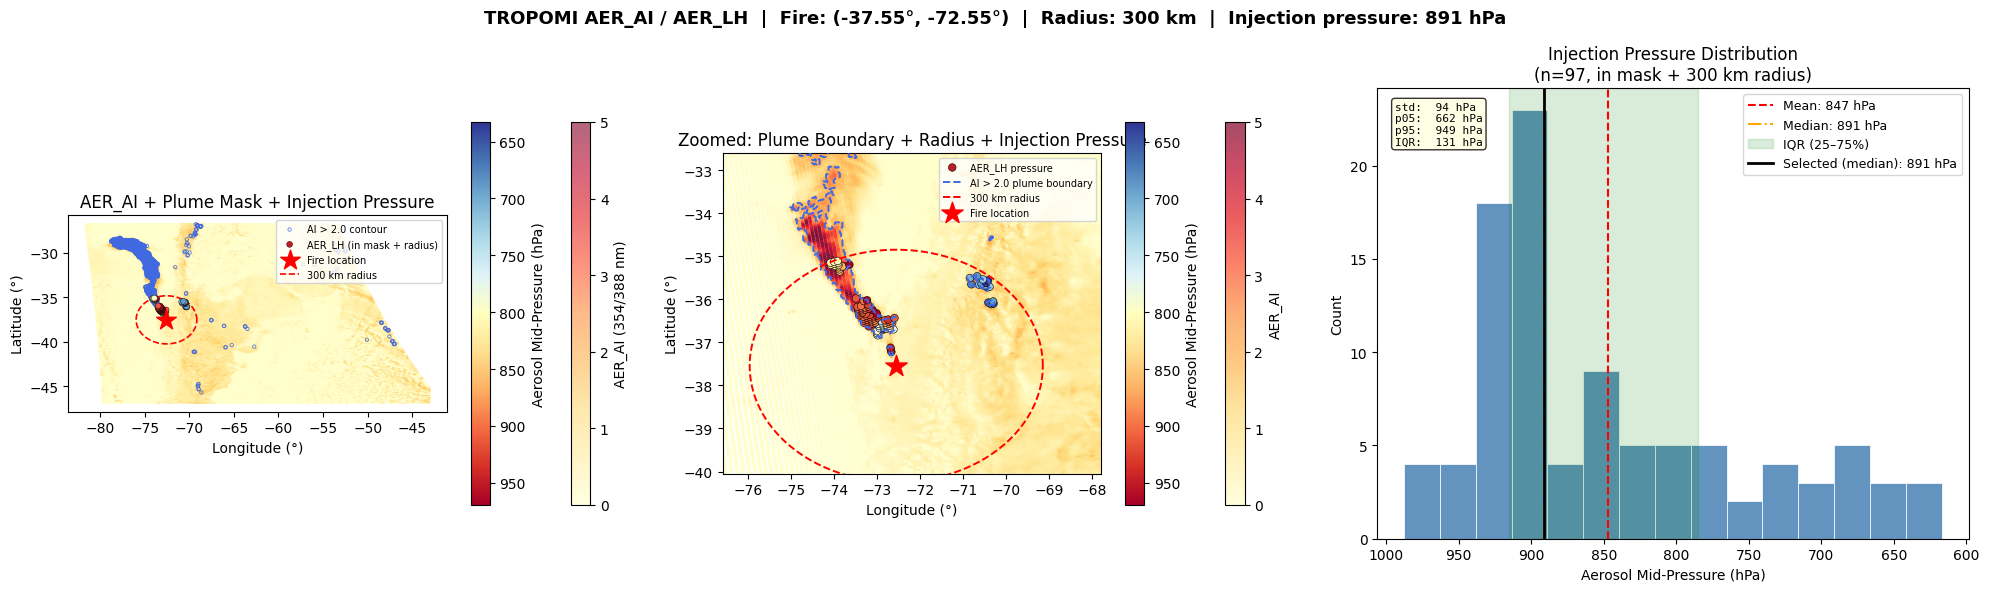

Plot saved to injection_pressure_analysis.png


In [8]:
ai_lat = ai_data["lat"]
ai_lon = ai_data["lon"]
ai_domain = ai_data["ai"]

alh_pres_domain = alh_data["alh_pres"]
alh_lat=alh_data["lat"]
alh_lon=alh_data["lon"]

# Reproduce the selection mask (mirrors reconciled function steps 1-3)
plume_mask_ai = (ai_domain > AI_THRESHOLD) & np.isfinite(ai_domain)
ai_lat_plume  = ai_lat[plume_mask_ai]
ai_lon_plume  = ai_lon[plume_mask_ai]

alh_finite   = np.isfinite(alh_pres_domain) & (alh_pres_domain > 0)
dist_alh_km  = _haversine_km(FIRE_LAT, FIRE_LON, alh_lat, alh_lon)
in_radius    = alh_finite & (dist_alh_km <= EXTRACTION_RADIUS_KM)

tree_ai  = cKDTree(_latlon_to_xyz(ai_lat, ai_lon))
_, nn_idx = tree_ai.query(_latlon_to_xyz(alh_lat[in_radius], alh_lon[in_radius]), k=1, workers=-1)
in_plume_v   = plume_mask_ai[nn_idx]

# Final combined mask indices (back into the original alh arrays)
in_radius_idx          = np.where(in_radius)[0]
final_idx              = in_radius_idx[in_plume_v]
alh_pres_selected_pa   = alh_pres_domain[final_idx]          # Pa
alh_pres_selected_hpa  = alh_pres_selected_pa / 100.0        # hPa
alh_lat_selected       = alh_lat[final_idx]
alh_lon_selected       = alh_lon[final_idx]

# Pressure stats (mirrors compute_stats from inline pipeline)
valid_hpa = alh_pres_selected_hpa[np.isfinite(alh_pres_selected_hpa)]
stats_pres = {
    "n"      : len(valid_hpa),
    "mean"   : float(np.mean(valid_hpa)),
    "median" : float(np.median(valid_hpa)),
    "std"    : float(np.std(valid_hpa)),
    "min"    : float(np.min(valid_hpa)),
    "max"    : float(np.max(valid_hpa)),
    "p25"    : float(np.percentile(valid_hpa, 25)),
    "p75"    : float(np.percentile(valid_hpa, 75)),
    "p05"    : float(np.percentile(valid_hpa, 5)),
    "p95"    : float(np.percentile(valid_hpa, 95)),
}

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    f"TROPOMI AER_AI / AER_LH  |  Fire: ({FIRE_LAT:.2f}°, {FIRE_LON:.2f}°)"
    f"  |  Radius: {EXTRACTION_RADIUS_KM} km"
    f"  |  Injection pressure: {injection_pressure_hpa:.0f} hPa",
    fontsize=13, fontweight="bold",
)

# Shared radius circle geometry
theta = np.linspace(0, 2 * np.pi, 360)
dlat  = np.rad2deg(EXTRACTION_RADIUS_KM / EARTH_RADIUS_KM)
dlon  = np.rad2deg(EXTRACTION_RADIUS_KM / (EARTH_RADIUS_KM * np.cos(np.deg2rad(FIRE_LAT))))

# ── Panel A: AER_AI map + plume contour + AER_LH pressure scatter ─────────
ax = axes[0]

sc_ai = ax.scatter(
    ai_lon, ai_lat,
    c=ai_domain, cmap="YlOrRd", s=0.8, alpha=0.6,
    vmin=0, vmax=max(5, np.nanpercentile(ai_domain, 99)),
    rasterized=True, label="_nolegend_",
)
plt.colorbar(sc_ai, ax=ax, label="AER_AI (354/388 nm)", shrink=0.85)

ax.scatter(
    ai_lon_plume, ai_lat_plume,
    c="none", edgecolors="royalblue", s=6, linewidths=0.5,
    label=f"AI > {AI_THRESHOLD} contour", rasterized=True,
)

if len(valid_hpa) > 0:
    # Pressure colormap: invert so low pressure (high altitude) = bright
    sc_lh = ax.scatter(
        alh_lon_selected, alh_lat_selected,
        c=alh_pres_selected_hpa, cmap="RdYlBu_r", s=18,
        edgecolors="k", linewidths=0.3,
        vmin=np.nanpercentile(alh_pres_selected_hpa, 2),
        vmax=np.nanpercentile(alh_pres_selected_hpa, 98),
        zorder=5, label="AER_LH (in mask + radius)",
    )
    cb = plt.colorbar(sc_lh, ax=ax, label="Aerosol Mid-Pressure (hPa)", shrink=0.85)
    cb.ax.invert_yaxis()   # low pressure (high altitude) at top

ax.scatter(FIRE_LON, FIRE_LAT, marker="*", s=220, c="red", zorder=10, label="Fire location")
ax.plot(
    FIRE_LON + dlon * np.cos(theta),
    FIRE_LAT + dlat * np.sin(theta),
    "r--", linewidth=1.2, label=f"{EXTRACTION_RADIUS_KM} km radius",
)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("AER_AI + Plume Mask + Injection Pressure")
ax.legend(fontsize=7, loc="upper right")
ax.set_aspect("equal")

# ── Panel B: Zoomed view — pressure over plume region ─────────────────────
ax2 = axes[1]

if len(valid_hpa) > 0:
    lon_pad, lat_pad = 2.5, 2.5
    lon_min_z = min(alh_lon_selected.min(), FIRE_LON) - lon_pad
    lon_max_z = max(alh_lon_selected.max(), FIRE_LON) + lon_pad
    lat_min_z = min(alh_lat_selected.min(), FIRE_LAT) - lat_pad
    lat_max_z = max(alh_lat_selected.max(), FIRE_LAT) + lat_pad

    zoom_ai = (
        (ai_lon >= lon_min_z) & (ai_lon <= lon_max_z) &
        (ai_lat >= lat_min_z) & (ai_lat <= lat_max_z)
    )
    sc_bg = ax2.scatter(
        ai_lon[zoom_ai], ai_lat[zoom_ai],
        c=ai_domain[zoom_ai], cmap="YlOrRd", s=4, alpha=0.7,
        vmin=0, vmax=max(5, np.nanpercentile(ai_domain, 99)),
        rasterized=True,
    )
    plt.colorbar(sc_bg, ax=ax2, label="AER_AI", shrink=0.85)

    sc_lh2 = ax2.scatter(
        alh_lon_selected, alh_lat_selected,
        c=alh_pres_selected_hpa, cmap="RdYlBu_r", s=30,
        edgecolors="k", linewidths=0.4,
        vmin=np.nanpercentile(alh_pres_selected_hpa, 2),
        vmax=np.nanpercentile(alh_pres_selected_hpa, 98),
        zorder=5, label="AER_LH pressure",
    )
    cb2 = plt.colorbar(sc_lh2, ax=ax2, label="Aerosol Mid-Pressure (hPa)", shrink=0.85)
    cb2.ax.invert_yaxis()

    # ── Plume mask contour via nearest-neighbour rasterisation ────────────
    # Rasterise plume_mask_ai onto a regular grid inside the zoom window,
    # then draw a single contour at the mask boundary (level = 0.5).
    n_grid      = 300
    lon_grid    = np.linspace(lon_min_z, lon_max_z, n_grid)
    lat_grid    = np.linspace(lat_min_z, lat_max_z, n_grid)
    LON_G, LAT_G = np.meshgrid(lon_grid, lat_grid)

    zoom_ai_idx  = np.where(zoom_ai)[0]
    ai_pts_zoom  = np.column_stack([ai_lat[zoom_ai], ai_lon[zoom_ai]])
    tree_zoom    = cKDTree(ai_pts_zoom)
    grid_pts     = np.column_stack([LAT_G.ravel(), LON_G.ravel()])
    _, gi        = tree_zoom.query(grid_pts, k=1, workers=-1)
    plume_grid   = plume_mask_ai[zoom_ai_idx[gi]].reshape(n_grid, n_grid).astype(float)

    ax2.contour(
        LON_G, LAT_G, plume_grid,
        levels=[0.5], colors=["royalblue"], linewidths=[1.4],
        linestyles=["--"], zorder=6,
    )
    ax2.plot([], [], color="royalblue", linestyle="--", linewidth=1.4,
             label=f"AI > {AI_THRESHOLD} plume boundary")

    # ── Radius circle ──────────────────────────────────────────────────────
    ax2.plot(
        FIRE_LON + dlon * np.cos(theta),
        FIRE_LAT + dlat * np.sin(theta),
        color="red", linestyle="--", linewidth=1.4,
        label=f"{EXTRACTION_RADIUS_KM} km radius", zorder=7,
    )

    # ── Fire marker ────────────────────────────────────────────────────────
    ax2.scatter(FIRE_LON, FIRE_LAT, marker="*", s=260, c="red",
                zorder=10, label="Fire location")

    ax2.set_xlim(lon_min_z, lon_max_z)
    ax2.set_ylim(lat_min_z, lat_max_z)
    ax2.legend(fontsize=7, loc="upper right")

ax2.set_xlabel("Longitude (°)")
ax2.set_ylabel("Latitude (°)")
ax2.set_title("Zoomed: Plume Boundary + Radius + Injection Pressure")
ax2.set_aspect("equal")

# ── Panel C: Histogram of injection pressure distribution ─────────────────
ax3 = axes[2]

if len(valid_hpa) > 0:
    n_bins = max(15, int(np.sqrt(len(valid_hpa))))
    ax3.hist(
        valid_hpa, bins=n_bins,
        color="steelblue", edgecolor="white", linewidth=0.6, alpha=0.85,
    )
    ax3.axvline(
        stats_pres["mean"], color="red", linestyle="--", linewidth=1.5,
        label=f"Mean: {stats_pres['mean']:.0f} hPa",
    )
    ax3.axvline(
        stats_pres["median"], color="orange", linestyle="-.", linewidth=1.5,
        label=f"Median: {stats_pres['median']:.0f} hPa",
    )
    ax3.axvspan(
        stats_pres["p25"], stats_pres["p75"],
        alpha=0.15, color="green", label="IQR (25–75%)",
    )
    # Mark the selected injection pressure
    ax3.axvline(
        injection_pressure_hpa, color="black", linestyle="-", linewidth=2.0,
        label=f"Selected ({psel['aggregation'] if 'aggregation' in psel else 'median'}): {injection_pressure_hpa:.0f} hPa",
        zorder=5,
    )
    ax3.set_xlabel("Aerosol Mid-Pressure (hPa)")
    ax3.set_ylabel("Count")
    ax3.set_title(
        f"Injection Pressure Distribution\n"
        f"(n={stats_pres['n']}, in mask + {EXTRACTION_RADIUS_KM} km radius)"
    )
    ax3.legend(fontsize=9)
    # Pressure axis: low hPa = high altitude, so invert for meteorological convention
    ax3.invert_xaxis()
    ax3.text(
        0.03, 0.97,
        f"std:  {stats_pres['std']:.0f} hPa\n"
        f"p05:  {stats_pres['p05']:.0f} hPa\n"
        f"p95:  {stats_pres['p95']:.0f} hPa\n"
        f"IQR:  {stats_pres['p75'] - stats_pres['p25']:.0f} hPa",
        transform=ax3.transAxes, ha="left", va="top",
        fontsize=8, family="monospace",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8),
    )
else:
    ax3.text(
        0.5, 0.5, "No AER_LH pixels\ninside mask + radius",
        ha="center", va="center", transform=ax3.transAxes, fontsize=12,
    )

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/injection_pressure_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to injection_pressure_analysis.png")

In [9]:
def find_overpass_time(no2_data: dict, fire_lat: float, fire_lon: float, pix_per_scan = 450) -> pd.Timestamp:
    """
    Find the overpass timestamp at the closest pixel to (fire_lat, fire_lon).

    Assumes time array is per-scanline and pixels are ordered scanline-major,
    i.e. pixels [i*pix_per_scan : (i+1)*pix_per_scan] belong to scanline i.

    Parameters
    ----------
    no2_data : dict with keys 'lat', 'lon', 'time' (as returned by your loader)
    fire_lat : float
    fire_lon : float

    Returns
    -------
    pd.Timestamp (UTC)
    """
    lats = no2_data["lat"]
    lons = no2_data["lon"]
    times = no2_data["time"]

    # Find closest pixel using squared distance (no trig needed at this scale)
    dlat = lats - fire_lat
    dlon = (lons - fire_lon) * np.cos(np.radians(fire_lat))  # approximate equal-area
    dist2 = dlat**2 + dlon**2

    closest_pixel_idx = int(np.argmin(dist2))
    scanline_idx = closest_pixel_idx // pix_per_scan

    raw_time = times[scanline_idx]
    if isinstance(raw_time, (bytes, np.bytes_)):
        raw_time = raw_time.decode("utf-8")

    return pd.Timestamp(raw_time).tz_localize(None)

OVERPASS_UTC = find_overpass_time(no2_data, FIRE_LAT, FIRE_LON)
print(OVERPASS_UTC)  # Timestamp('2026-01-18 18:27:...')

2026-01-18 18:00:06.324000


In [10]:
era5 = xr.open_dataset(ERA5_PL_PATH)
time_dim = "valid_time" if "valid_time" in era5.dims else "time"
era5_t = era5.sel({time_dim: OVERPASS_UTC}, method="nearest")

# ── Sanity check: selected ERA5 time must be within ±1 h of overpass ──
selected_time = pd.Timestamp(era5_t[time_dim].values)
time_diff = abs(selected_time - OVERPASS_UTC)
print(f"OVERPASS_UTC:      {OVERPASS_UTC}")
print(f"ERA5 selected time: {selected_time}")
print(f"Time difference:    {time_diff}")
assert time_diff <= pd.Timedelta("1h"), (
    f"ERA5 nearest time ({selected_time}) is {time_diff} away from "
    f"overpass ({OVERPASS_UTC}) — exceeds ±1 h tolerance. "
    f"Check ERA5 file coverage."
)

# Nearest ERA5 grid point to fire centre
era5_lat_key = "latitude" if "latitude" in era5_t.coords else "lat"
era5_lon_key = "longitude" if "longitude" in era5_t.coords else "lon"
era5_lats = era5_t[era5_lat_key].values
era5_lons = era5_t[era5_lon_key].values

i_lat = int(np.argmin(np.abs(era5_lats - FIRE_LAT)))
i_lon = int(np.argmin(np.abs(era5_lons - FIRE_LON)))

u_profile = era5_t["u"].isel(**{era5_lat_key: i_lat, era5_lon_key: i_lon}).values.ravel()
v_profile = era5_t["v"].isel(**{era5_lat_key: i_lat, era5_lon_key: i_lon}).values.ravel()
p_levels  = era5_t["pressure_level"].values.ravel()  # hPa, descending

print(f"ERA5 grid point: {era5_lats[i_lat]:.2f}°N, {era5_lons[i_lon]:.2f}°E")
print(f"Pressure levels: {p_levels.min():.0f}–{p_levels.max():.0f} hPa ({len(p_levels)} levels)")

# ── Log-pressure interpolation ────────────────────────────────────────
sort_idx  = np.argsort(p_levels)   # ascending pressure order
p_sorted  = p_levels[sort_idx]
u_sorted  = u_profile[sort_idx]
v_sorted  = v_profile[sort_idx]

def interp_log_p(p_target_hpa, p_sorted, u_sorted, v_sorted):
    'Log-pressure interpolation for a single target level.'
    log_p = np.log(p_sorted)
    u_i = float(np.interp(np.log(p_target_hpa), log_p, u_sorted))
    v_i = float(np.interp(np.log(p_target_hpa), log_p, v_sorted))
    return u_i, v_i

# ── Extract wind at injection pressure (set in Section 3a) ───────────
# injection_pressure_hpa is defined in the AER_AI/AER_LH cell that
# precedes this in execution order (Section 3a, inserted before Section 3).
# If that cell has not run yet, fall back to 900 hPa.
_p_extract = injection_pressure_hpa if "injection_pressure_hpa" in dir() else 900.0
U_WIND, V_WIND = interp_log_p(_p_extract, p_sorted, u_sorted, v_sorted)
WIND_SPEED = float(np.hypot(U_WIND, V_WIND))
THETA_RAD  = float(np.arctan2(V_WIND, U_WIND))
WIND_SOURCE = pressure_source if "pressure_source" in dir() else f"ERA5 {_p_extract:.0f} hPa"
print(f"\nWind at {_p_extract:.0f} hPa ({WIND_SOURCE}):")
print(f"  U={U_WIND:+.2f}, V={V_WIND:+.2f} m/s, speed={WIND_SPEED:.2f} m/s, "
      f"θ={np.degrees(THETA_RAD):.1f}°")

OVERPASS_UTC:      2026-01-18 18:00:06.324000
ERA5 selected time: 2026-01-18 18:00:00
Time difference:    0 days 00:00:06.324000
ERA5 grid point: -37.50°N, -72.50°E
Pressure levels: 125–975 hPa (13 levels)

Wind at 891 hPa (ERA5 891 hPa):
  U=-3.82, V=+8.02 m/s, speed=8.88 m/s, θ=115.5°


---
## Section 4 — Wind-Frame Coordinate Rotation (Step-by-Step)

**Algorithm (Jin et al. 2021 Section 2.3):**

1. Convert (lat, lon) offsets from fire centre to Cartesian (x_km, y_km) using
   equirectangular projection with cos(lat) correction on the x axis.
2. Rotate by θ = arctan2(v, u) (wind direction, CCW from east): downwind axis = x_rot,
   cross-wind axis = y_rot.
3. Bin onto a regular grid.

In [11]:
# ── Extract NO₂ pixels within scene radius ────────────────────────────────
# Restored from Audit 2 (session restart): radius uses EXTRACTION_RADIUS_KM
# Use L2 flat arrays from Section 1 (lat_all, lon_all, no2_all)

# Vectorised haversine on L2 flat arrays
phi0, phi_all = np.radians(FIRE_LAT), np.radians(lat_domain)
dlambda_all = np.radians(lon_domain - FIRE_LON)
dphi_all    = phi_all - phi0
a_hav = np.sin(dphi_all/2)**2 + np.cos(phi0)*np.cos(phi_all)*np.sin(dlambda_all/2)**2
dist_km_all = 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.clip(a_hav, 0, 1)))

scene_mask = (dist_km_all <= EXTRACTION_RADIUS_KM) & np.isfinite(no2_domain)
lat_s  = lat_domain[scene_mask]
lon_s  = lon_domain[scene_mask]
no2_s  = no2_domain[scene_mask]
dist_s = dist_km_all[scene_mask]

assert len(lat_s) > 0, \
    f"No valid NO₂ pixels within {EXTRACTION_RADIUS_KM} km of fire centre."

print(f"Scene pixels (radius={EXTRACTION_RADIUS_KM} km): {len(lat_s)}")
print(f"NO₂ range in scene: [{np.nanmin(no2_s):.4e}, {np.nanmax(no2_s):.4e}] mol m⁻²")

# ── Step 1: Cartesian projection ──────────────────────────────────────────
m_per_deg_lon = M_PER_DEG_LAT * np.cos(np.radians(FIRE_LAT))
x_km = (lon_s - FIRE_LON) * m_per_deg_lon / 1000.0
y_km = (lat_s - FIRE_LAT) * M_PER_DEG_LAT / 1000.0

# ── Step 2: Wind direction from ERA5 at injection pressure ────────────────
# U_WIND, V_WIND, WIND_SPEED, THETA_RAD, WIND_SOURCE come from Section 3 ERA5 cell
U_WIND_USE = U_WIND
V_WIND_USE = V_WIND
theta_use  = THETA_RAD
print(f"Using ERA5 at {injection_pressure_hpa:.0f} hPa ({WIND_SOURCE}): "
      f"U={U_WIND:.2f}, V={V_WIND:.2f} m/s, speed={WIND_SPEED:.2f} m/s")

# ── Step 3: Wind-frame rotation ──────────────────────────────────────────
cos_t = np.cos(theta_use)
sin_t = np.sin(theta_use)
x_rot = x_km * cos_t + y_km * sin_t    # downwind (positive = downwind of fire)
y_rot = -x_km * sin_t + y_km * cos_t   # cross-wind

print(f"\nRotated coordinates range:")
print(f"  x_rot (downwind): [{x_rot.min():.1f}, {x_rot.max():.1f}] km")
print(f"  y_rot (cross-wind): [{y_rot.min():.1f}, {y_rot.max():.1f}] km")

Scene pixels (radius=300 km): 7545
NO₂ range in scene: [-1.7800e-05, 5.6690e-04] mol m⁻²
Using ERA5 at 891 hPa (ERA5 891 hPa): U=-3.82, V=8.02 m/s, speed=8.88 m/s

Rotated coordinates range:
  x_rot (downwind): [-301.0, 299.1] km
  y_rot (cross-wind): [-297.9, 300.7] km


In [12]:
# ── Step 4: Binning onto regular grid ─────────────────────────────────────
half = GRID_DY_KM / 2.0
x_edges = np.arange(X_MIN_KM, X_MAX_KM + 1e-9, GRID_DY_KM)
y_edges = np.arange(-Y_MAX_KM - half, Y_MAX_KM + half + 1e-9, GRID_DY_KM)
x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])
nx, ny = len(x_centres), len(y_centres)

ix = np.digitize(x_rot, x_edges) - 1
iy = np.digitize(y_rot, y_edges) - 1
valid_bins = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)

grid_sum = np.zeros((nx, ny))
grid_cnt = np.zeros((nx, ny), dtype=int)
for k in np.where(valid_bins)[0]:
    grid_sum[ix[k], iy[k]] += no2_s[k]
    grid_cnt[ix[k], iy[k]] += 1

grid_mean = np.where(grid_cnt > 0, grid_sum / grid_cnt, np.nan).astype(np.float32)
print(f"Grid shape: {nx} × {ny} (downwind × cross-wind)")
print(f"Filled cells: {(grid_cnt > 0).sum()} / {nx*ny}")

Grid shape: 72 × 37 (downwind × cross-wind)
Filled cells: 1986 / 2664


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_38421/3974494946.py:19: RuntimeWarning: invalid value encountered in divide
  grid_mean = np.where(grid_cnt > 0, grid_sum / grid_cnt, np.nan).astype(np.float32)


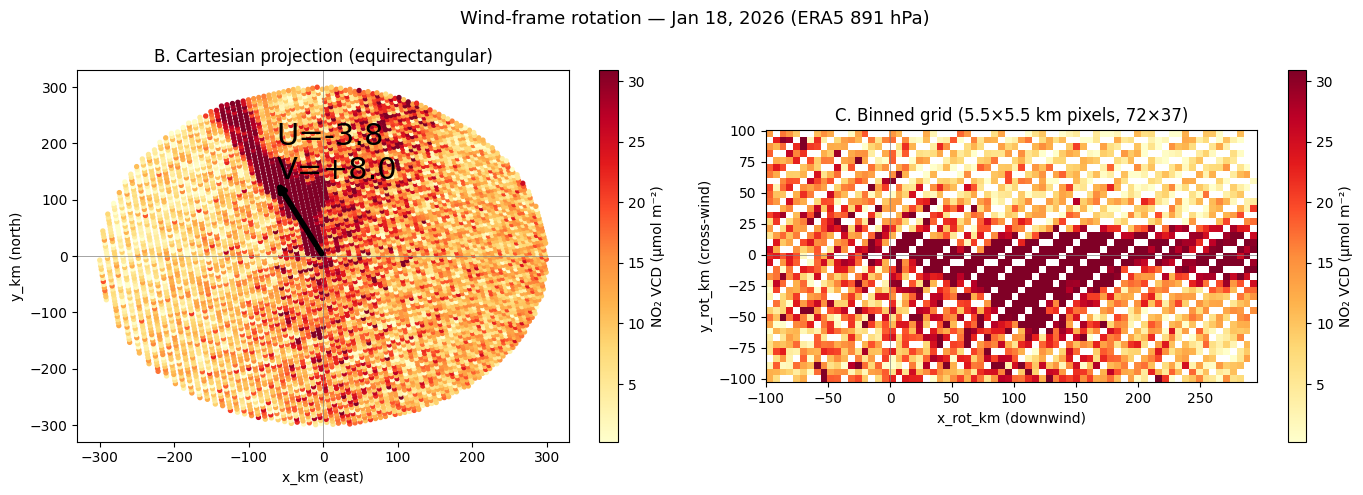

In [13]:
# ── 2×2 panel figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel B: Cartesian
ax = axes[0]
sc = ax.scatter(x_km, y_km, c=no2_s * 1e6, s=8, cmap="YlOrRd", vmin=_minp_bg, vmax=_maxp_bg)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
arrow_scale = 150.0
ax.annotate("", xy=(U_WIND * arrow_scale / WIND_SPEED, V_WIND * arrow_scale / WIND_SPEED),
            xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="black", lw=4))
ax.text(U_WIND * arrow_scale / WIND_SPEED + 2, V_WIND * arrow_scale / WIND_SPEED + 2,
        f"U={U_WIND:+.1f}\nV={V_WIND:+.1f}", fontsize=22, color="black")
plt.colorbar(sc, ax=ax, label="NO₂ VCD (µmol m⁻²)")
ax.set_xlabel("x_km (east)"); ax.set_ylabel("y_km (north)")
ax.set_title("B. Cartesian projection (equirectangular)")

# Panel C: binned grid — pixel-accurate aspect ratio
ax = axes[1]
im = ax.pcolormesh(x_centres, y_centres, grid_mean.T * 1e6,
                   cmap="YlOrRd", vmin=_minp_bg, vmax=_maxp_bg)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect(1.0)
plt.colorbar(im, ax=ax, label="NO₂ VCD (µmol m⁻²)")
ax.set_xlabel("x_rot_km (downwind)"); ax.set_ylabel("y_rot_km (cross-wind)")
ax.set_title(f"C. Binned grid ({GRID_DY_KM}×{GRID_DY_KM} km pixels, {nx}×{ny})")

fig.suptitle(f"Wind-frame rotation — Jan {FIRE_DATE.split('-')[-1]}, 2026 ({WIND_SOURCE})", fontsize=13)
fig.tight_layout()
plt.savefig(OUT_DIR / "eda_s4_rotation.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5 — Line Density Computation

**Critical:** the EMG is fit to the **line density** L(x) [mol m⁻¹], NOT
the column average [mol m⁻²]. The pipeline currently uses `nanmean` (wrong).
The correct formula is:

    L[i] = nansum(ΔNO₂[i, :]) × Δy_m   [mol m⁻¹]

We compute both and show the difference explicitly.

In [14]:
# ── ΔNO₂ grid ─────────────────────────────────────────────────────────────
dno2_grid = grid_mean.astype(np.float64)
dno2_grid[grid_cnt == 0] = np.nan   # unfilled cells → NaN (not negative)
dno2_nozero = np.where(np.isfinite(dno2_grid) & (dno2_grid != 0), dno2_grid, np.nan)

# ── CORRECT approach (paper): nansum × Δy [mol m⁻¹] ─────────────────────
profile = np.nansum(
    np.where(np.isfinite(dno2_nozero), dno2_nozero, 0.0), axis=1
) * GRID_DY_M  # mol m⁻²  × m = mol m⁻¹
# Set rows with no valid pixels to NaN
has_valid = np.any(np.isfinite(dno2_nozero), axis=1)
profile = np.where(has_valid, profile, np.nan)

# ── Count of valid cross-wind cells per downwind position ─────────────────
n_valid_y = np.sum(np.isfinite(dno2_nozero), axis=1)

print(f"\nGrid: {nx} downwind × {ny} cross-wind cells")
print(f"Mean valid cross-wind cells per row: {n_valid_y.mean():.1f}")
print(f"Correct profile peak: {np.nanmax(profile):.4e} mol m⁻¹")


Grid: 72 downwind × 37 cross-wind cells
Mean valid cross-wind cells per row: 27.6
Correct profile peak: 1.4169e+01 mol m⁻¹


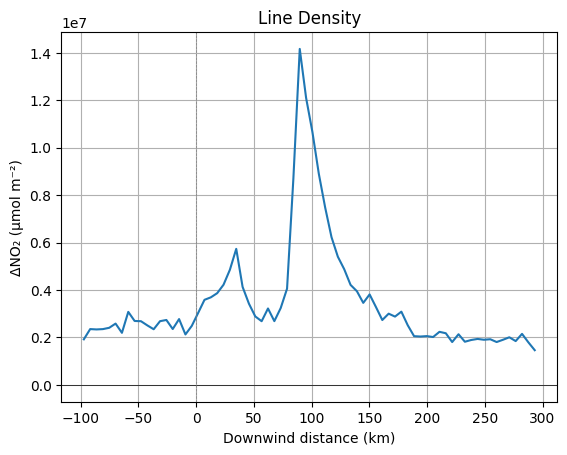

In [15]:
plt.plot(x_centres, profile * 1e6, "C0-")
plt.xlabel("Downwind distance (km)")
plt.ylabel("ΔNO₂ (µmol m⁻²)")
plt.title("Line Density")
plt.axhline(0, color="k", lw=0.5); 
plt.axvline(0, color="gray", lw=0.5, ls="--")
plt.grid()

plt.savefig(OUT_DIR / "nox_line_density.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Section 6 — EMG Fit

The EMG function (Beirle et al. 2011, eq. 1):

    L(x; a, x0, μ, σ, B) =
        (a / x0) · exp(μ/x0 + σ²/(2x0²) − x/x0)
        · Φ((x−μ)/σ − σ/x0) + B

Parameters:
- `a` [mol m⁻¹]: emission–lifetime product E·τ  
- `x0` [km]: U·τ (wind × lifetime)
- `μ` [km]: source offset from origin  
- `σ` [km]: along-wind Gaussian spread  
- `B` [mol m⁻¹]: residual background line density

Derived quantities: τ = x0/U, E = a/τ = a·U/x0

In [16]:
# ── EMG function ──────────────────────────────────────────────────────────
def emg(x, a, x0, mu_x, sigma_x, B):
    """EMG line density profile [mol m⁻¹]."""
    x = np.asarray(x, dtype=float)
    x0 = max(x0, 1e-6)
    sigma_x = max(sigma_x, 1e-6)
    exponent = mu_x/x0 + sigma_x**2/(2*x0**2) - x/x0
    exponent = np.clip(exponent, -500.0, 500.0)
    phi_arg = (x - mu_x)/sigma_x - sigma_x/x0
    return (a/x0) * np.exp(exponent) * ndtr(phi_arg) + B

# ── Fit EMG to Jan 18 line density (correct version) ──────────────────────
x_fit_all = x_centres
y_fit_all = profile

finite_mask = np.isfinite(y_fit_all)
x_fit = x_fit_all[finite_mask]
y_fit = y_fit_all[finite_mask]

if len(x_fit) < 10:
    print("WARNING: fewer than 10 finite profile points. Check background subtraction.")
    a_med = x0_med = mu_med = sig_med = B_med = np.nan
else:
    # Initial guess
    y_max = float(np.nanmax(y_fit))
    y_min = float(np.nanmin(y_fit))
    x_peak = float(x_fit[np.argmax(y_fit)])

    p0 = [y_max * 50.0, 50.0, x_peak * 0.5, 30.0, float(y_min)]
    bounds_lo = [0.0,   1.0, -200.0, 1.0, -1e6]
    bounds_hi = [np.inf, 500.0, 200.0, 200.0, float(max(y_max, 1.0))]

    # 50-run stability test
    rng = np.random.default_rng(42)
    success_params = []
    for _ in range(50):
        pert = rng.uniform(0.8, 1.2, size=5)
        p0_p = np.clip(np.array(p0) * pert, bounds_lo, bounds_hi)
        try:
            popt, _ = curve_fit(emg, x_fit, y_fit, p0=p0_p,
                                bounds=(bounds_lo, bounds_hi), maxfev=5000)
            if np.all(np.isfinite(popt)) and popt[0] > 0 and popt[1] > 0:
                success_params.append(popt)
        except (RuntimeError, ValueError):
            continue

    print(f"EMG fitting: {len(success_params)} / 50 runs converged")

    if success_params:
        params_arr = np.array(success_params)
        pmed = np.median(params_arr, axis=0)
        a_med, x0_med, mu_med, sig_med, B_med = pmed

        # Stability: CV(E_emg) as per paper
        U_kph = WIND_SPEED * 3.6
        E_vals = (params_arr[:, 0] / params_arr[:, 1]) * U_kph * 1000.0 / 3600.0
        cv_E = np.std(E_vals) / np.mean(E_vals)
        cv_a = np.std(params_arr[:, 0]) / np.mean(params_arr[:, 0])
        fit_stable_paper = cv_E <= 0.5
        fit_stable_pipeline = cv_a <= 0.5

        tau_h = x0_med / U_kph
        E_mol_per_s = (a_med / x0_med) * U_kph * 1000.0 / 3600.0
        E_nox_g_per_s = E_mol_per_s * NOX_NO2_RATIO_GAMMA * NO2_MOLAR_MASS_G_PER_MOL

        y_pred = emg(x_fit, *pmed)
        ss_res = np.sum((y_fit - y_pred)**2)
        ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

        print(f"\nEMG fit results (correct line density):")
        print(f"  a = {a_med:.4e} mol m⁻¹, x0 = {x0_med:.1f} km")
        print(f"  μ = {mu_med:.1f} km, σ = {sig_med:.1f} km, B = {B_med:.4e} mol m⁻¹")
        print(f"  τ = {tau_h:.2f} h, E = {E_mol_per_s:.2f} mol/s = {E_nox_g_per_s:.1f} g/s NOₓ")
        print(f"  R² = {r2:.3f}")
        print(f"  CV(a) = {cv_a:.3f} (pipeline metric, stable={fit_stable_pipeline})")
        print(f"  CV(E) = {cv_E:.3f} (paper metric, stable={fit_stable_paper})")
        print(f"  Note: GEOS-Chem a priori bias → true emissions ~{E_nox_g_per_s/0.55:.0f} g/s (Jin 2021 Table S6)")

        # ── Criterion 3: peak within 30 km of fire centre ─────────────────
        # Peak of the fitted EMG (found numerically)
        x_dense = np.linspace(-50, 150, 10000)
        L_dense  = emg(x_dense, a_med, x0_med, mu_med, sig_med, 0.0)
        x_peak_fit = float(x_dense[np.argmax(L_dense)])
        peak_ok = abs(x_peak_fit) <= 30.0
        status3 = "PASS ✓" if peak_ok else "FAIL ✗"
        print(f"\nCriterion 3 — peak within 30 km of fire centre:")
        print(f"  Fitted peak position: x={x_peak_fit:.1f} km  [{status3}]")
        if not peak_ok:
            print("  WARNING: peak is far from origin — scene may be misaligned or wrong fire centre.")
    else:
        a_med = x0_med = mu_med = sig_med = B_med = np.nan
        print("WARNING: no converged fits.")

EMG fitting: 50 / 50 runs converged

EMG fit results (correct line density):
  a = 3.4991e+02 mol m⁻¹, x0 = 21.3 km
  μ = 84.8 km, σ = 4.2 km, B = 2.5962e+00 mol m⁻¹
  τ = 0.67 h, E = 145.79 mol/s = 8853.2 g/s NOₓ
  R² = 0.907
  CV(a) = 0.063 (pipeline metric, stable=True)
  CV(E) = 2.556 (paper metric, stable=False)
  Note: GEOS-Chem a priori bias → true emissions ~16097 g/s (Jin 2021 Table S6)

Criterion 3 — peak within 30 km of fire centre:
  Fitted peak position: x=90.9 km  [FAIL ✗]


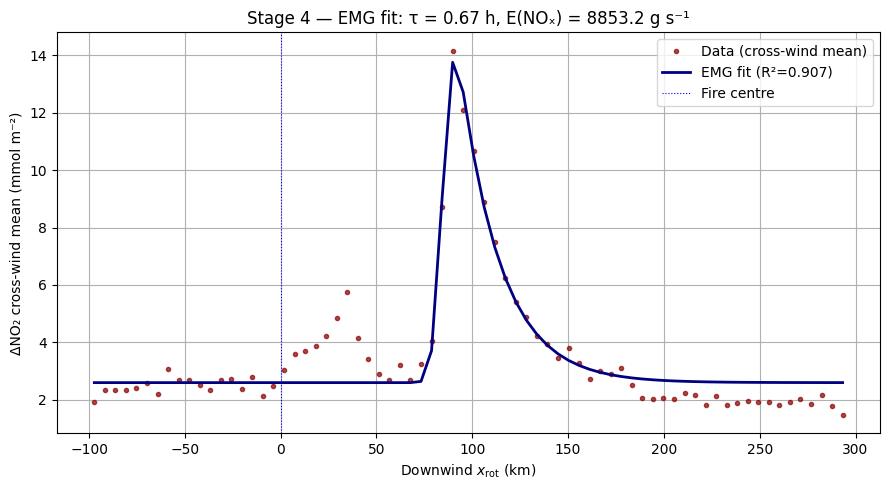

Saved: /Users/maperezc/Downloads/wildfires/outputs/nox_final/0118/stage4_emg_fit.png


In [17]:
# ── Stage 4 diagnostic: EMG fit to along-wind profile ──────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_fit, y_fit, "o", ms=3, color="darkred", alpha=0.7, label="Data (cross-wind mean)")
ax.plot(x_fit, y_pred, "-", lw=2, color="navy",
        label=f"EMG fit (R²={r2:.3f})")
#ax.axhline(bg_mol_m2 * 1e5, color="gray", lw=1, ls="--", label="Background B")
ax.axvline(0, color="blue", lw=0.8, ls=":", label="Fire centre")
ax.set(
    title=f"Stage 4 — EMG fit: τ = {tau_h:.2f} h, "
          f"E(NOₓ) = {E_nox_g_per_s:.1f} g s⁻¹",
    xlabel="Downwind $x_{\\mathrm{rot}}$ (km)",
    ylabel="ΔNO₂ cross-wind mean (mmol m⁻²)",
)
ax.legend()
ax.grid()
plt.tight_layout()
fig.savefig(OUT_DIR / "stage4_emg_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'stage4_emg_fit.png'}")

AER_AI plume median (891 hPa)                : 8.88 m/s, E=8801.7 g/s NOx
850 hPa                                      : 6.45 m/s, E=7094.7 g/s NOx
875 hPa                                      : 8.70 m/s, E=9923.0 g/s NOx
900 hPa (fallback)                           : 9.19 m/s, E=8807.1 g/s NOx


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_38421/2089652674.py:29: RuntimeWarning: invalid value encountered in divide
  gm_i = np.where(gc_i > 0, gs_i / gc_i, np.nan)


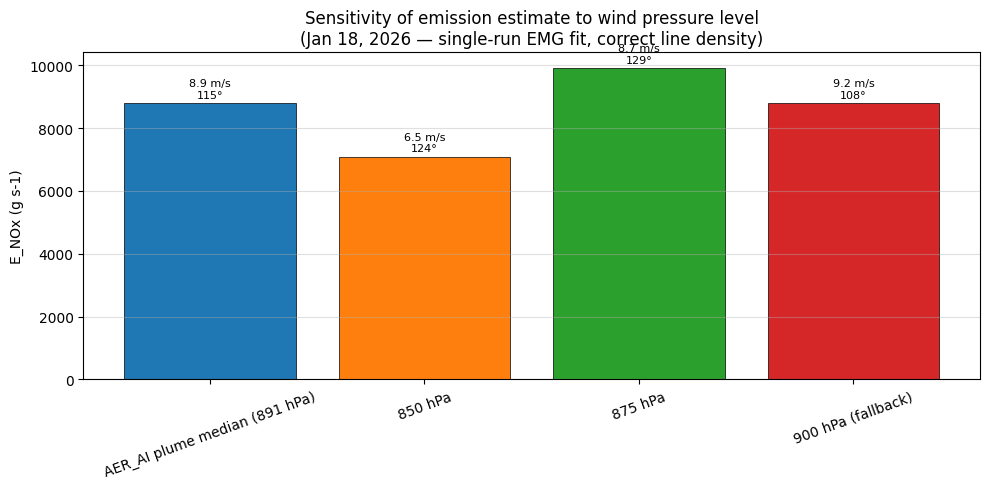

AER_AI plume median (891 hPa): +24.1% vs 900 hPa baseline
850 hPa: +0.0% vs 900 hPa baseline
875 hPa: +39.9% vs 900 hPa baseline


In [18]:

# AER_AI-derived injection pressure (from select_injection_pressure in Section 3a)
_label_alh = f"AER_AI plume median ({injection_pressure_hpa:.0f} hPa)"
scenarios = [
    (_label_alh,          injection_pressure_hpa),
    ("850 hPa",             850.0),
    ("875 hPa",             875.0),
    ("900 hPa (fallback)",  900.0),
    
]
results = []
for label, p_hpa in scenarios:
    u_i, v_i = interp_log_p(p_hpa, p_sorted, u_sorted, v_sorted)
    spd = float(np.hypot(u_i, v_i))
    theta_i = float(np.arctan2(v_i, u_i))

    # Re-rotate to this wind direction
    cos_i, sin_i = np.cos(theta_i), np.sin(theta_i)
    x_rot_i = x_km * cos_i + y_km * sin_i
    y_rot_i = -x_km * sin_i + y_km * cos_i

    # Re-bin
    ix_i = np.digitize(x_rot_i, x_edges) - 1
    iy_i = np.digitize(y_rot_i, y_edges) - 1
    valid_i = (ix_i >= 0) & (ix_i < nx) & (iy_i >= 0) & (iy_i < ny)
    gs_i = np.zeros((nx, ny)); gc_i = np.zeros((nx, ny), dtype=int)
    for k in np.where(valid_i)[0]:
        gs_i[ix_i[k], iy_i[k]] += no2_s[k]
        gc_i[ix_i[k], iy_i[k]] += 1
    gm_i = np.where(gc_i > 0, gs_i / gc_i, np.nan)

    # Background + line density
    upwind_x_i = x_rot_i[(x_rot_i < -20) & (x_rot_i > -100)]
    upwind_no2_i = no2_s[(x_rot_i < -20) & (x_rot_i > -100)]
    bg_i = float(np.nanmedian(upwind_no2_i)) if len(upwind_no2_i) >= 10 else bg_mol_m2

    dn_i = (gm_i - bg_i)
    dn_i[gc_i == 0] = np.nan
    dn_nz = np.where(np.isfinite(dn_i) & (dn_i != 0), dn_i, np.nan)
    prof_i = np.nansum(np.where(np.isfinite(dn_nz), dn_nz, 0.0), axis=1) * GRID_DY_M
    prof_i[~np.any(np.isfinite(dn_nz), axis=1)] = np.nan

    # Quick EMG fit (single run from p0_base)
    fm_i = np.isfinite(prof_i)
    E_nox_gs = np.nan
    if fm_i.sum() >= 10:
        xf, yf = x_centres[fm_i], prof_i[fm_i]
        ym = float(np.nanmax(yf))
        p0_i = [ym * 50.0, 50.0, float(xf[np.argmax(yf)] * 0.5), 30.0, float(np.nanmin(yf))]
        try:
            popt_i, _ = curve_fit(
                emg, xf, yf, p0=p0_i,
                bounds=([0, 1, -200, 1, -1e6], [np.inf, 500, 200, 200, float(max(ym, 1.0))]),
                maxfev=5000
            )
            a_i, x0_i = popt_i[0], popt_i[1]
            E_mol_i = (a_i / x0_i) * spd * 3.6 * 1000.0 / 3600.0
            E_nox_gs = E_mol_i * NOX_NO2_RATIO_GAMMA * NO2_MOLAR_MASS_G_PER_MOL
        except (RuntimeError, ValueError):
            pass

    results.append({
        "label": label, "p_hpa": p_hpa, "speed_ms": spd,
        "theta_deg": np.degrees(theta_i), "E_nox_gs": E_nox_gs
    })
    print(f"{label:45s}: {spd:.2f} m/s, E={E_nox_gs:.1f} g/s NOx")

# ── Bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
labels_p = [r["label"] for r in results]
E_vals_p = [r["E_nox_gs"] if np.isfinite(r["E_nox_gs"]) else 0.0 for r in results]
colors = ["C0", "C1", "C2", "C3"]
bars = ax.bar(labels_p, E_vals_p, color=colors, edgecolor="k", linewidth=0.5)
ax.set_ylabel("E_NOx (g s-1)")
ax.set_title("Sensitivity of emission estimate to wind pressure level\n(Jan 18, 2026 — single-run EMG fit, correct line density)")
ax.tick_params(axis="x", rotation=20)
for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(E_vals_p),
            f"{r['speed_ms']:.1f} m/s\n{r['theta_deg']:.0f}°",
            ha="center", va="bottom", fontsize=8)
ax.grid(axis="y", alpha=0.4)
fig.tight_layout()
plt.savefig(OUT_DIR / "eda_s7_wind_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show()

if len([r for r in results if np.isfinite(r["E_nox_gs"])]) >= 2:
    E_ref = results[1]["E_nox_gs"]  # 900 hPa
    for r in results:
        if np.isfinite(r["E_nox_gs"]) and r["p_hpa"] != 900:
            pct_diff = (r["E_nox_gs"] - E_ref) / E_ref * 100.0
            print(f"{r['label']}: {pct_diff:+.1f}% vs 900 hPa baseline")